# Cargar datos y generar los conjuntos de entrenamiento y test

In [88]:
import pandas as pd

# file_path = 'data_set_limpio.pkl'
file_path = 'datasets_pkl/data_set_limpio_sin_not_for_sale.pkl'

df = pd.read_pickle(file_path)

# Display the loaded DataFrame
# print(df)

In [ ]:
import pandas as pd
visualizar_todo=False
if visualizar_todo:
    # Show all rows
    pd.set_option('display.max_rows', None)

    # Show all columns
    pd.set_option('display.max_columns', None)

    # Show full content of each cell (prevent text truncation)
    pd.set_option('display.max_colwidth', None)


## Dataframe solo con features numericas

In [72]:
import numpy as np
# Create new dataframe with only numeric columns
only_numeric_df = df.select_dtypes(include=[np.number])

# # Optional: Create a separate dataframe for non-numeric columns
# only_categoric_df = df.select_dtypes(exclude=[np.number])


## Generar conjuntos de entrenamiento y test

In [73]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
def train_test_sets(df):
    # To get the data as a new DataFrame
    X = df.loc[:, df.columns != 'transfer_value_estimado']
    y= df.loc[:, df.columns == 'transfer_value_estimado']
    rs=18
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=rs)

    cat_columns = X_train.select_dtypes(exclude=['number']).columns

    # 2. Convert them to the 'category' dtype for both train and test
    for col in cat_columns:
        X_train[col] = X_train[col].astype(str)
        X_test[col] = X_test[col].astype(str)
    return X,y,X_train,X_test,y_train,y_test,cat_columns


In [74]:
X,y,X_train,X_test,y_train,y_test,cat_columns=train_test_sets(only_numeric_df)

# LinearRegression

Entrenamiento y evaluación

r2 train:  0.47501849628655346
coeficientes de la regresión  [[  7209.33633148  -1716.15904537 -23781.70832969     83.00713698
   -2412.91230811  -1640.04936405 -26819.86077466   6994.79282049
    9460.7171163    7064.48362942   7319.82745305  10397.19210851
   16480.11445428 -15079.48893918  13000.39217423   6437.50232113
     361.57251031  21801.0276406   17386.55721374 -12423.69077911
     343.26319263  22739.57419995   8509.66378335  10355.87159675
   16308.16601602   3736.04279931    915.14825832  27464.65363257
    9389.66836801  16730.2991219   -5480.70539473  -6529.00327376
   -2660.67613569   4338.19429194 -14161.53096022 -14001.77077805
    2044.03255077  14865.25885057   4234.79235622  -5864.06572921
    8873.43767148   2092.40750486   5136.90990408   5069.86167539
   -5149.56823138  -6476.10393736  -8730.34727374  15130.06597804
   13206.80112987   8153.36468109  -6769.47042478  -6720.59260702
    4154.94950392  18188.99290607  11100.61042988]]
intercepto de la regresión  [

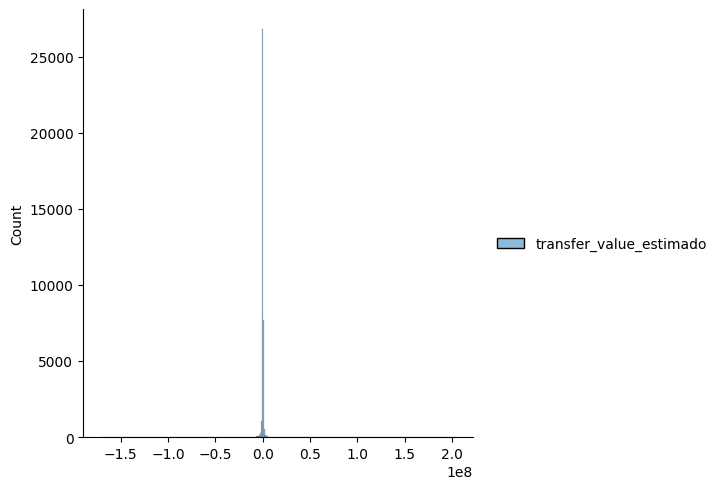

In [ ]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(X_train, y_train)

r2_score_train=reg.score(X_train, y_train)
print("r2 train: ",r2_score_train)
print("coeficientes de la regresión ",reg.coef_)
print("intercepto de la regresión ",reg.intercept_)

import seaborn as sns
y_pred=reg.predict(X_test)
r2_score_test=reg.score(X_test, y_test)
print("r2 test: ",r2_score_test)
residual = y_test - y_pred
sns.displot(residual)

# Ridge

In [ ]:
from sklearn.linear_model import ridge_regression


# Lasso

# ElasticNet